In [1]:
# ============================================================
# Ridge Volatility Forecasting Model
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ------------------------------------------------------------
# 1. Load data
# ------------------------------------------------------------

df = pd.read_csv("data/clean_monthly_panel_with_3regimes.csv")

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(["permno", "date"])

# ------------------------------------------------------------
# 2. Define predictors
# ------------------------------------------------------------

features = [
    "real_vol_ann_lag1",
    "real_vol_ann_lag2",
    "real_vol_ann_lag3",
    "ret_lag1",
    "ret_lag3",
    "ret_lag6",
    "abs_ret_lag1",
    "mktcap_lag1",
    "momentum_12m",
    "liquidity"
]

target = "real_vol_ann"

# ------------------------------------------------------------
# 3. Drop missing values
# ------------------------------------------------------------

model_df = df.dropna(subset=features + [target]).copy()

# ------------------------------------------------------------
# 4. Rolling prediction setup
# ------------------------------------------------------------

ridge_predictions = []

dates = sorted(model_df["date"].unique())

start_test_idx = 60  # ~5 years training

for i in range(start_test_idx, len(dates)):

    train_dates = dates[:i]
    test_date = dates[i]

    train = model_df[model_df["date"].isin(train_dates)]
    test = model_df[model_df["date"] == test_date]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]

    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10.0))
    ])

    ridge_model.fit(X_train, y_train)

    test = test.copy()

    test["predicted_vol"] = ridge_model.predict(X_test)

    ridge_predictions.append(test)

ridge_pred_df = pd.concat(ridge_predictions)

# ------------------------------------------------------------
# 5. Construct monthly portfolio
# ------------------------------------------------------------

ridge_results = []

for date, month_df in ridge_pred_df.groupby("date"):

    available = month_df.dropna(subset=["predicted_vol", "ret"])

    if len(available) < 500:
        continue

    selected = available.nsmallest(500, "predicted_vol").copy()

    capital_cost_rate = np.where(
        selected["high_vol_regime"],
        0.30,
        0.15
    )

    selected["capital_cost"] = (
        capital_cost_rate * selected["predicted_vol"] / 12
    )

    selected["net_return"] = (
        selected["ret"] - selected["capital_cost"]
    )

    ridge_results.append({
        "date": date,
        "avg_net_return": selected["net_return"].mean(),
        "avg_gross_return": selected["ret"].mean(),
        "avg_predicted_vol": selected["predicted_vol"].mean(),
        "high_vol_regime": selected["high_vol_regime"].iloc[0]
    })

ridge_monthly = pd.DataFrame(ridge_results)

ridge_monthly["cumulative_net_return"] = (
    1 + ridge_monthly["avg_net_return"]
).cumprod()

ridge_monthly["running_max"] = (
    ridge_monthly["cumulative_net_return"].cummax()
)

ridge_monthly["drawdown"] = (
    ridge_monthly["cumulative_net_return"]
    / ridge_monthly["running_max"] - 1
)

ridge_monthly.head()

,date,avg_net_return,avg_gross_return,avg_predicted_vol,high_vol_regime,cumulative_net_return,running_max,drawdown
0,1996-01-31,0.015080,0.015657,0.046106,False,1.015080,1.015080,0.0
1,1996-02-29,0.010091,0.010676,0.046805,False,1.025323,1.025323,0.0
2,1996-03-31,0.011235,0.011846,0.048851,False,1.036842,1.036842,0.0
3,1996-04-30,0.000703,0.001327,0.049990,False,1.037571,1.037571,0.0
4,1996-05-31,0.012883,0.013513,0.050415,False,1.050938,1.050938,0.0


In [2]:
# ============================================================
# Lasso Volatility Forecasting Model
# ============================================================

from sklearn.linear_model import Lasso

lasso_predictions = []

for i in range(start_test_idx, len(dates)):

    train_dates = dates[:i]
    test_date = dates[i]

    train = model_df[model_df["date"].isin(train_dates)]
    test = model_df[model_df["date"] == test_date]

    X_train = train[features]
    y_train = train[target]

    X_test = test[features]

    lasso_model = Pipeline([
        ("scaler", StandardScaler()),
        ("lasso", Lasso(alpha=0.0005, max_iter=5000))
    ])

    lasso_model.fit(X_train, y_train)

    test = test.copy()

    test["predicted_vol"] = lasso_model.predict(X_test)

    lasso_predictions.append(test)

lasso_pred_df = pd.concat(lasso_predictions)

# ------------------------------------------------------------
# Construct monthly portfolio
# ------------------------------------------------------------

lasso_results = []

for date, month_df in lasso_pred_df.groupby("date"):

    available = month_df.dropna(subset=["predicted_vol", "ret"])

    if len(available) < 500:
        continue

    selected = available.nsmallest(500, "predicted_vol").copy()

    capital_cost_rate = np.where(
        selected["high_vol_regime"],
        0.30,
        0.15
    )

    selected["capital_cost"] = (
        capital_cost_rate * selected["predicted_vol"] / 12
    )

    selected["net_return"] = (
        selected["ret"] - selected["capital_cost"]
    )

    lasso_results.append({
        "date": date,
        "avg_net_return": selected["net_return"].mean(),
        "avg_gross_return": selected["ret"].mean(),
        "avg_predicted_vol": selected["predicted_vol"].mean(),
        "high_vol_regime": selected["high_vol_regime"].iloc[0]
    })

lasso_monthly = pd.DataFrame(lasso_results)

lasso_monthly["cumulative_net_return"] = (
    1 + lasso_monthly["avg_net_return"]
).cumprod()

lasso_monthly["running_max"] = (
    lasso_monthly["cumulative_net_return"].cummax()
)

lasso_monthly["drawdown"] = (
    lasso_monthly["cumulative_net_return"]
    / lasso_monthly["running_max"] - 1
)

lasso_monthly.head()

,date,avg_net_return,avg_gross_return,avg_predicted_vol,high_vol_regime,cumulative_net_return,running_max,drawdown
0,1996-01-31,0.015665,0.016258,0.047408,False,1.015665,1.015665,0.0
1,1996-02-29,0.010248,0.010849,0.048137,False,1.026074,1.026074,0.0
2,1996-03-31,0.011907,0.012533,0.050092,False,1.038291,1.038291,0.0
3,1996-04-30,0.000740,0.001379,0.051159,False,1.039059,1.039059,0.0
4,1996-05-31,0.013433,0.014079,0.051643,False,1.053017,1.053017,0.0


   Model Avg Monthly Net Return Avg Annual Net Return Std Monthly Net Return  \
0  Ridge                  0.92%                11.56%                  3.09%   
1  Lasso                  0.92%                11.58%                  3.08%   

  Sharpe Ratio Total Cumulative Return Max Drawdown Normal Month Return  \
0         1.03                   18.22      -38.21%               1.06%   
1         1.03                   18.34      -38.11%               1.06%   

  Crisis Month Return  
0              -1.00%  
1              -0.99%  


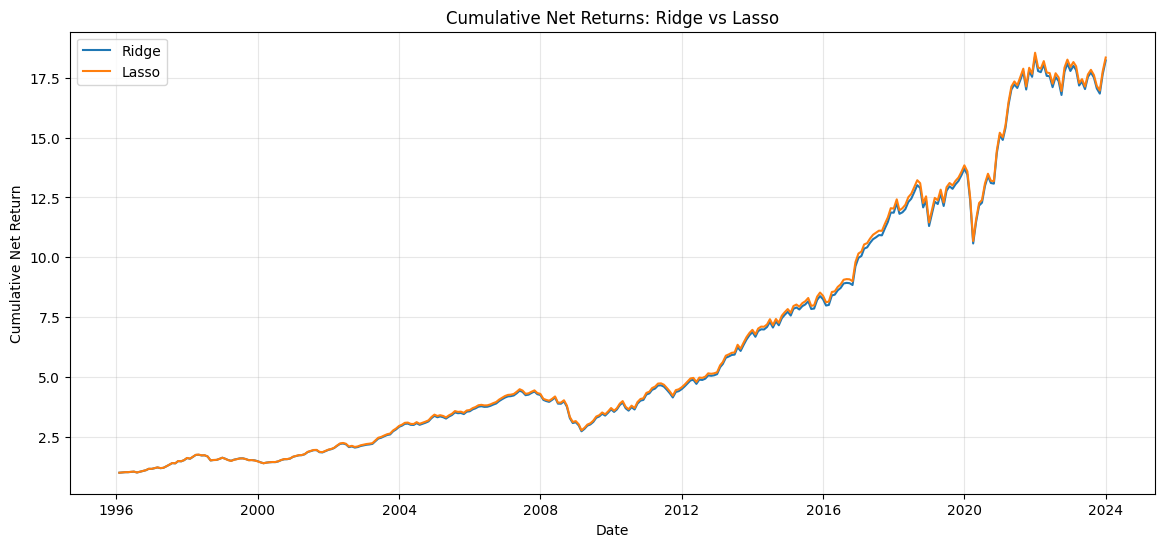

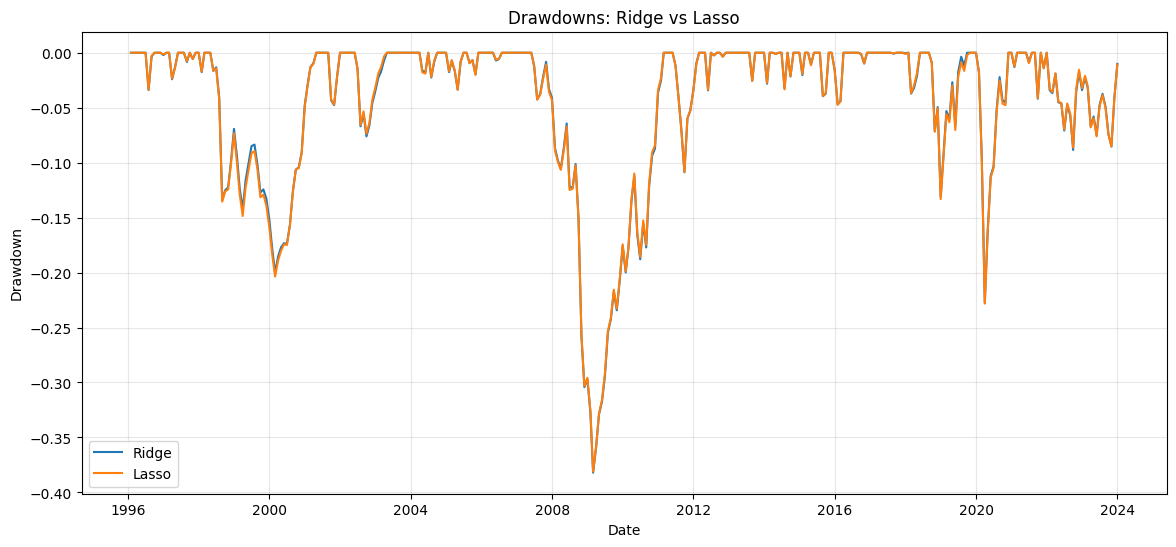

In [3]:
# ============================================================
# Compare Ridge vs Lasso
# ============================================================

def summarize_strategy(monthly_df, label):

    avg_monthly = monthly_df["avg_net_return"].mean()

    avg_annual = (
        (1 + avg_monthly) ** 12 - 1
    )

    std_monthly = monthly_df["avg_net_return"].std()

    sharpe = (
        avg_monthly / std_monthly * np.sqrt(12)
    )

    total_cumulative = (
        monthly_df["cumulative_net_return"].iloc[-1]
    )

    max_drawdown = (
        monthly_df["drawdown"].min()
    )

    best_idx = monthly_df["avg_net_return"].idxmax()
    worst_idx = monthly_df["avg_net_return"].idxmin()

    crisis_months = monthly_df[
        monthly_df["high_vol_regime"] == True
    ]

    normal_months = monthly_df[
        monthly_df["high_vol_regime"] == False
    ]

    return {
        "Model": label,
        "Avg Monthly Net Return": avg_monthly,
        "Avg Annual Net Return": avg_annual,
        "Std Monthly Net Return": std_monthly,
        "Sharpe Ratio": sharpe,
        "Total Cumulative Return": total_cumulative,
        "Max Drawdown": max_drawdown,
        "Normal Month Return": normal_months["avg_net_return"].mean(),
        "Crisis Month Return": crisis_months["avg_net_return"].mean()
    }


comparison = pd.DataFrame([
    summarize_strategy(ridge_monthly, "Ridge"),
    summarize_strategy(lasso_monthly, "Lasso")
])

comparison_display = comparison.copy()

percent_cols = [
    "Avg Monthly Net Return",
    "Avg Annual Net Return",
    "Std Monthly Net Return",
    "Max Drawdown",
    "Normal Month Return",
    "Crisis Month Return"
]

for col in percent_cols:
    comparison_display[col] = (
        comparison_display[col]
        .map(lambda x: f"{x:.2%}")
    )

comparison_display["Sharpe Ratio"] = (
    comparison_display["Sharpe Ratio"]
    .map(lambda x: f"{x:.2f}")
)

comparison_display["Total Cumulative Return"] = (
    comparison_display["Total Cumulative Return"]
    .map(lambda x: f"{x:.2f}")
)

print(comparison_display)

# ------------------------------------------------------------
# Plot cumulative performance
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    ridge_monthly["date"],
    ridge_monthly["cumulative_net_return"],
    label="Ridge"
)

plt.plot(
    lasso_monthly["date"],
    lasso_monthly["cumulative_net_return"],
    label="Lasso"
)

plt.title("Cumulative Net Returns: Ridge vs Lasso")
plt.xlabel("Date")
plt.ylabel("Cumulative Net Return")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# Plot drawdowns
# ------------------------------------------------------------

plt.figure(figsize=(14,6))

plt.plot(
    ridge_monthly["date"],
    ridge_monthly["drawdown"],
    label="Ridge"
)

plt.plot(
    lasso_monthly["date"],
    lasso_monthly["drawdown"],
    label="Lasso"
)

plt.title("Drawdowns: Ridge vs Lasso")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [4]:
coef_df = pd.DataFrame({
    "feature": features,
    "lasso_coef": lasso_model.named_steps["lasso"].coef_
})

print(coef_df)

             feature  lasso_coef
0  real_vol_ann_lag1    0.027855
1  real_vol_ann_lag2    0.016529
2  real_vol_ann_lag3    0.015558
3           ret_lag1   -0.008098
4           ret_lag3   -0.007131
5           ret_lag6   -0.000091
6       abs_ret_lag1    0.008175
7        mktcap_lag1   -0.000872
8       momentum_12m   -0.000000
9          liquidity    0.006670


Selected stock observation:

PERMNO: 11896
DATE: 1991-06-30 00:00:00

RIDGE LIME EXPLANATION
0.06 < real_vol_ann_lag1 <= 0.09         -0.02033
abs_ret_lag1 > 0.14                      0.01990
ret_lag3 > 0.05                          -0.01679
ret_lag1 > 0.07                          -0.01634
0.06 < real_vol_ann_lag3 <= 0.09         -0.01133
0.00 < liquidity <= 0.00                 -0.00315
ret_lag6 > 0.04                          -0.00242
momentum_12m > 0.40                      -0.00183

LASSO LIME EXPLANATION
0.06 < real_vol_ann_lag1 <= 0.09         -0.01984
abs_ret_lag1 > 0.14                      0.01765
ret_lag3 > 0.05                          -0.01527
ret_lag1 > 0.07                          -0.01465
0.06 < real_vol_ann_lag3 <= 0.09         -0.01413
0.00 < liquidity <= 0.00                 -0.00490
0.09 < real_vol_ann_lag2 <= 0.14         -0.00274
momentum_12m > 0.40                      0.00067

PREDICTED VOLATILITY COMPARISON
Actual realized volatility: 0.1457
Ridge predicted vo

/Users/meadijkstra/Library/Mobile Documents/com~apple~CloudDocs/Uni/Uni 2025-2026/AI in Finance elective/assignment/ai-finance-project/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/meadijkstra/Library/Mobile Documents/com~apple~CloudDocs/Uni/Uni 2025-2026/AI in Finance elective/assignment/ai-finance-project/.venv/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


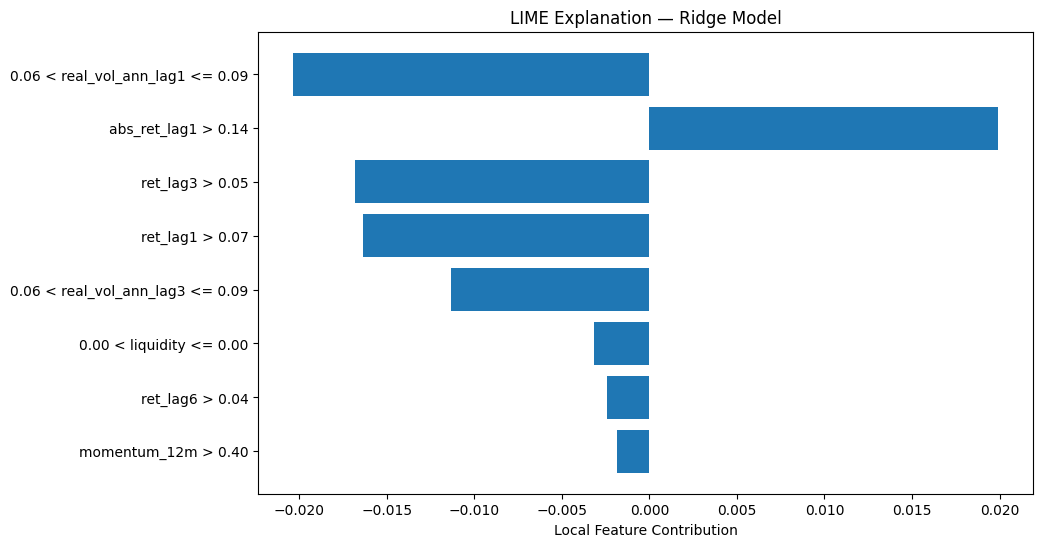

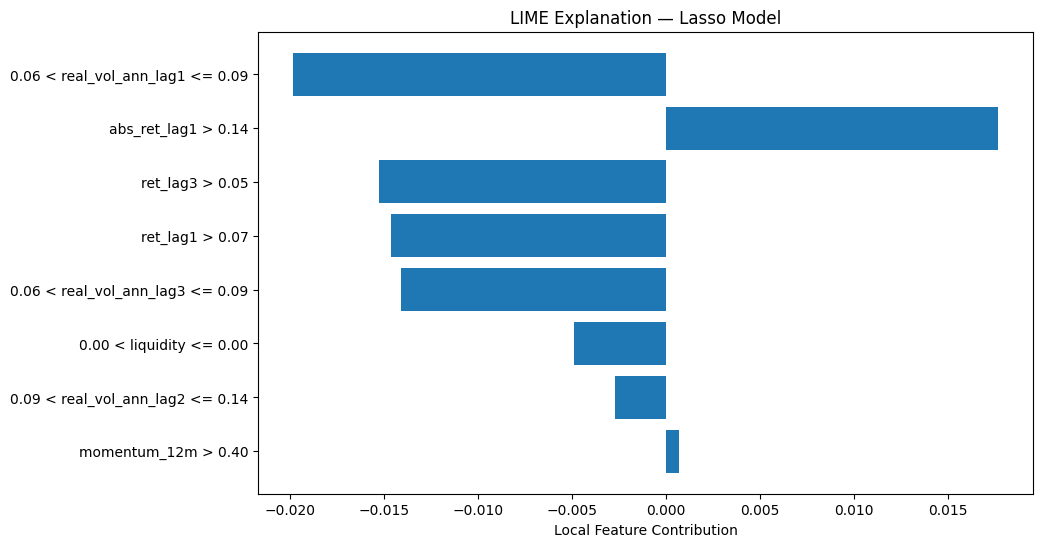


RIDGE VS LASSO LIME COMPARISON
                            feature  ridge_weight  lasso_weight
0          0.00 < liquidity <= 0.00     -0.003153     -0.004903
1  0.06 < real_vol_ann_lag1 <= 0.09     -0.020332     -0.019841
2  0.06 < real_vol_ann_lag3 <= 0.09     -0.011326     -0.014128
3  0.09 < real_vol_ann_lag2 <= 0.14           NaN     -0.002741
4               abs_ret_lag1 > 0.14      0.019903      0.017654
5               momentum_12m > 0.40     -0.001832      0.000665
6                   ret_lag1 > 0.07     -0.016341     -0.014648
7                   ret_lag3 > 0.05     -0.016791     -0.015272
8                   ret_lag6 > 0.04     -0.002415           NaN


In [6]:
# ============================================================
# LIME Explanation: Ridge vs Lasso
# Single Random Stock Observation
# ============================================================

# Install if needed:
# pip install lime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer

# ------------------------------------------------------------
# 1. Use same modelling dataset
# ------------------------------------------------------------

lime_df = model_df.copy()

# ------------------------------------------------------------
# 2. Select ONE random stock observation
# ------------------------------------------------------------

np.random.seed(42)

random_idx = np.random.choice(lime_df.index)

sample_obs = lime_df.loc[random_idx]

print("Selected stock observation:")
print()
print("PERMNO:", sample_obs["permno"])
print("DATE:", sample_obs["date"])
print()

# Features only
x_instance = sample_obs[features].values

# ------------------------------------------------------------
# 3. Refit Ridge and Lasso on FULL dataset
# (for stable explanation)
# ------------------------------------------------------------

X_full = lime_df[features]
y_full = lime_df[target]

ridge_model.fit(X_full, y_full)
lasso_model.fit(X_full, y_full)

# ------------------------------------------------------------
# 4. Create LIME explainer
# ------------------------------------------------------------

explainer = LimeTabularExplainer(
    training_data=np.array(X_full),
    feature_names=features,
    mode="regression",
    discretize_continuous=True,
    random_state=42
)

# ------------------------------------------------------------
# 5. Ridge explanation
# ------------------------------------------------------------

ridge_exp = explainer.explain_instance(
    data_row=x_instance,
    predict_fn=ridge_model.predict,
    num_features=8
)

print("=" * 70)
print("RIDGE LIME EXPLANATION")
print("=" * 70)

for feature, weight in ridge_exp.as_list():
    print(f"{feature:40s} {weight:.5f}")

# ------------------------------------------------------------
# 6. Lasso explanation
# ------------------------------------------------------------

lasso_exp = explainer.explain_instance(
    data_row=x_instance,
    predict_fn=lasso_model.predict,
    num_features=8
)

print()
print("=" * 70)
print("LASSO LIME EXPLANATION")
print("=" * 70)

for feature, weight in lasso_exp.as_list():
    print(f"{feature:40s} {weight:.5f}")

# ------------------------------------------------------------
# 7. Compare predicted volatility
# ------------------------------------------------------------

ridge_pred = ridge_model.predict(
    pd.DataFrame([x_instance], columns=features)
)[0]

lasso_pred = lasso_model.predict(
    pd.DataFrame([x_instance], columns=features)
)[0]

actual_vol = sample_obs[target]

print()
print("=" * 70)
print("PREDICTED VOLATILITY COMPARISON")
print("=" * 70)

print(f"Actual realized volatility: {actual_vol:.4f}")
print(f"Ridge predicted volatility: {ridge_pred:.4f}")
print(f"Lasso predicted volatility: {lasso_pred:.4f}")

# ------------------------------------------------------------
# 8. Plot Ridge explanation
# ------------------------------------------------------------

ridge_list = ridge_exp.as_list()

ridge_features = [x[0] for x in ridge_list]
ridge_weights = [x[1] for x in ridge_list]

plt.figure(figsize=(10, 6))

plt.barh(ridge_features[::-1], ridge_weights[::-1])

plt.title("LIME Explanation — Ridge Model")
plt.xlabel("Local Feature Contribution")
plt.show()

# ------------------------------------------------------------
# 9. Plot Lasso explanation
# ------------------------------------------------------------

lasso_list = lasso_exp.as_list()

lasso_features = [x[0] for x in lasso_list]
lasso_weights = [x[1] for x in lasso_list]

plt.figure(figsize=(10, 6))

plt.barh(lasso_features[::-1], lasso_weights[::-1])

plt.title("LIME Explanation — Lasso Model")
plt.xlabel("Local Feature Contribution")
plt.show()

# ------------------------------------------------------------
# 10. Side-by-side comparison dataframe
# ------------------------------------------------------------

ridge_df = pd.DataFrame(ridge_list, columns=["feature", "ridge_weight"])
lasso_df = pd.DataFrame(lasso_list, columns=["feature", "lasso_weight"])

lime_compare = ridge_df.merge(
    lasso_df,
    on="feature",
    how="outer"
)

print()
print("=" * 70)
print("RIDGE VS LASSO LIME COMPARISON")
print("=" * 70)

print(lime_compare)